# Synthetic Irregular 1D

Generates data from a known 2-component functional PCA model on [0,1]
and checks that the fitted functions recover the true structure.

In [ ]:
from __future__ import annotations

import matplotlib.pyplot as plt
import torch

from irregpca import IrregPCA, IrregPCAConfig, LiveLossPlotCallback

torch.manual_seed(42)

def true_mean(t: torch.Tensor) -> torch.Tensor:
    return t

def true_phi1(t: torch.Tensor) -> torch.Tensor:
    return torch.cos(2 * torch.pi * t) / torch.norm(torch.cos(2 * torch.pi * t))

def true_phi2(t: torch.Tensor) -> torch.Tensor:
    return torch.sin(2 * torch.pi * t) / torch.norm(torch.sin(2 * torch.pi * t))

eigvals = torch.tensor([4.0, 1.0])

In [41]:
# Sample irregular observations
n_samples = 200
obs_per = 50
sigma = 0.05

ids_list, locs_list, vals_list = [], [], []
for i in range(n_samples):
    s1 = torch.randn(1).item()
    s2 = torch.randn(1).item()
    t = torch.rand(obs_per, 1)
    y = (
        true_mean(t.squeeze())
        + eigvals[0] * s1 * true_phi1(t.squeeze())
        + eigvals[1] * s2 * true_phi2(t.squeeze())
        + sigma * torch.randn(obs_per)
    )
    ids_list.append(torch.full((obs_per,), float(i)))
    locs_list.append(t)
    vals_list.append(y)

sample_ids = torch.cat(ids_list)
locations  = torch.cat(locs_list, dim=0)
values     = torch.cat(vals_list)

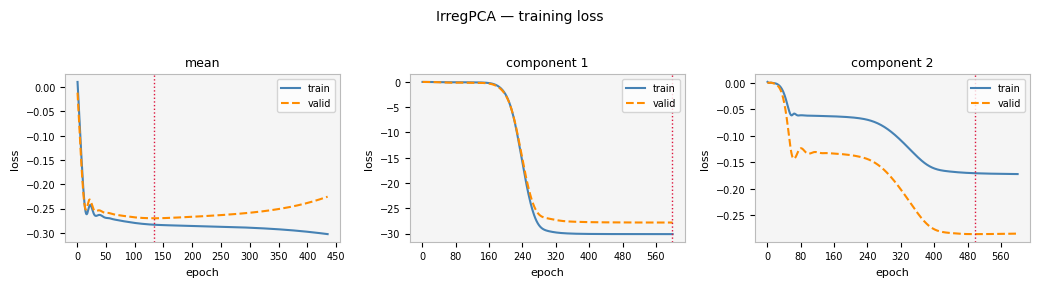


===> Training mean
  Early stop at epoch 434. Best epoch: 133.25489


===> Training component 0
  epoch  599 | train -30.115011 | valid -27.824343

===> Training component 1
  epoch  599 | train -0.172151 | valid -0.284557


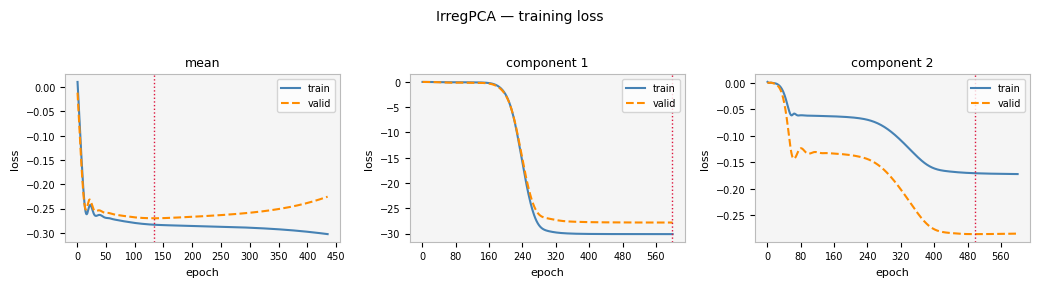

In [42]:
# Fit with live loss visualization
loss_cb = LiveLossPlotCallback(save_path="synthetic_irregular_1d_loss.png")

cfg = IrregPCAConfig(
    n_components=2,
    epochs=600,
    lr=0.001,
    patience=300,
    random_state=42,
    verbose=True,
    hidden_width=30,
    hidden_depth=2,
)
est = IrregPCA(config=cfg, callbacks=[loss_cb])
result = est.fit(sample_ids=sample_ids, locations=locations, values=values)

In [43]:
# Compare on a dense grid
grid = torch.linspace(0, 1, 500).unsqueeze(-1)
mu_hat = result.mean(grid).cpu().squeeze()
mu_true = true_mean(grid.squeeze())

mse_mean = ((mu_hat - mu_true) ** 2).mean()
print(f"Mean MSE on grid: {mse_mean:.6f}")
print(f"Best epochs per model: {result.history.best_epochs}")
print(f"Gram matrix of components:\n{result.orthogonality_matrix()}")

Mean MSE on grid: 0.012937
Best epochs per model: [133, 599, 499]
Gram matrix of components:
tensor([[ 7.7523, -0.0664],
        [-0.0664,  0.5750]], device='mps:0')


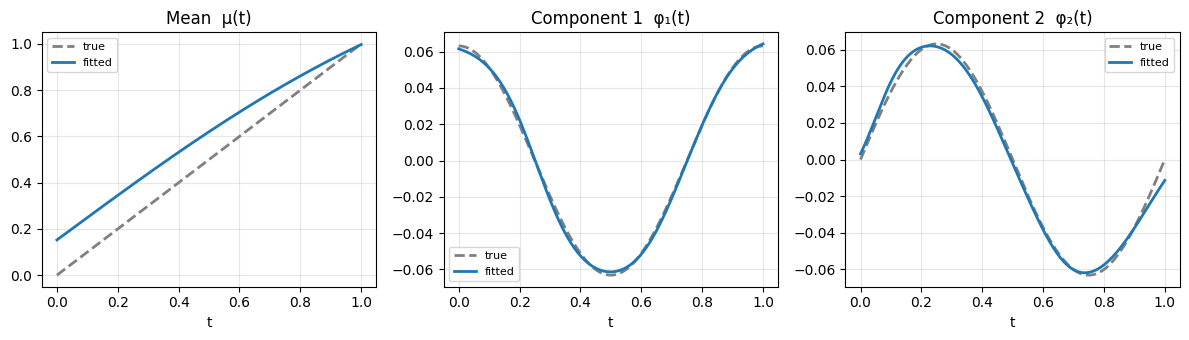

In [46]:
# Plot fitted vs true functions
t = grid.squeeze().cpu().numpy()

phi1_tr = true_phi1(grid).cpu().numpy()
phi1_tr = phi1_tr / torch.norm(torch.from_numpy(phi1_tr))
phi2_tr = true_phi2(grid).cpu().numpy()
phi2_tr = phi2_tr / torch.norm(torch.from_numpy(phi2_tr))

phi1_hat = result.component(0, grid).cpu().numpy()
phi1_hat /= torch.norm(torch.from_numpy(phi1_hat))
phi1_hat *= -torch.sign((phi1_hat * phi1_tr).sum()) # Align sign
phi2_hat = result.component(1, grid).cpu().numpy()
phi2_hat /= torch.norm(torch.from_numpy(phi2_hat))
phi2_hat *= torch.sign((phi2_hat * phi2_tr).sum())  # Align sign

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
pairs = [
    (mu_hat.cpu().numpy(), mu_true.cpu().numpy(), "Mean  μ(t)"),
    (phi1_hat, phi1_tr, "Component 1  φ₁(t)"),
    (phi2_hat, phi2_tr, "Component 2  φ₂(t)"),
]
for ax, (fitted, truth, title) in zip(axes, pairs):
    ax.plot(t, truth, lw=2, color="gray", linestyle="--", label="true")
    ax.plot(t, fitted.squeeze(), lw=2, label="fitted")
    ax.set_title(title)
    ax.set_xlabel("t")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("synthetic_irregular_1d_example.png", dpi=150)
plt.show()